1. Objective

This task focuses on evaluating fairness in machine learning models used in real-world systems such as credit approval. While traditional evaluation relies on overall accuracy, fairness analysis ensures that the model performs consistently across different demographic groups and does not disadvantage specific populations.

The goal is to:

Evaluate model performance across groups
Analyze sensitive and proxy features
Detect bias and unfair treatment
Understand real-world impact

 2. Dataset Description


The dataset used is the German Credit Dataset from UCI Machine Learning Repository.

Total samples: 1000
Features: 20
Target: Credit risk (Good / Bad)


 The model predicts whether a person is:

1 → Good credit

0 → Bad credit

In [24]:
!pip install ucimlrepo pandas scikit-learn matplotlib seaborn

In [25]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.ensemble import RandomForestClassifier

Load Dataset

In [40]:
data = fetch_ucirepo(id=144)

X = data.data.features
y = data.data.targets

df = pd.concat([X, y], axis=1)
df.head()
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 21)


Data Understanding

In [27]:
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Attribute1   1000 non-null   object
 1   Attribute2   1000 non-null   int64 
 2   Attribute3   1000 non-null   object
 3   Attribute4   1000 non-null   object
 4   Attribute5   1000 non-null   int64 
 5   Attribute6   1000 non-null   object
 6   Attribute7   1000 non-null   object
 7   Attribute8   1000 non-null   int64 
 8   Attribute9   1000 non-null   object
 9   Attribute10  1000 non-null   object
 10  Attribute11  1000 non-null   int64 
 11  Attribute12  1000 non-null   object
 12  Attribute13  1000 non-null   int64 
 13  Attribute14  1000 non-null   object
 14  Attribute15  1000 non-null   object
 15  Attribute16  1000 non-null   int64 
 16  Attribute17  1000 non-null   object
 17  Attribute18  1000 non-null   int64 
 18  Attribute19  1000 non-null   object
 19  Attribute20  1000 non-null  

Index(['Attribute1', 'Attribute2', 'Attribute3', 'Attribute4', 'Attribute5',
       'Attribute6', 'Attribute7', 'Attribute8', 'Attribute9', 'Attribute10',
       'Attribute11', 'Attribute12', 'Attribute13', 'Attribute14',
       'Attribute15', 'Attribute16', 'Attribute17', 'Attribute18',
       'Attribute19', 'Attribute20', 'class'],
      dtype='object')

Rename Columns

In [28]:
df.rename(columns={
    "class": "Target",
    "personal_status": "Sex"
}, inplace=True)

Preprocessing

Preprocessing is the process of cleaning and transforming raw data into a format suitable for machine learning.

In [29]:
df["Target"] = df["Target"].replace({2: 0})


le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

Feature Engineering


Feature engineering is the process of creating new features to improve model performance.

In [30]:
# Age groups
df["AgeGroup"] = df["Attribute13"].apply(lambda x: 0 if x < 30 else 1)

Train-Test Split


Splitting data ensures that the model is evaluated on unseen data.

In [31]:
X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Model Training


A classification model predicts categorical outcomes.

In [41]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.78


Evaluation Metrics


Accuracy: Overall correctness
Recall: Ability to detect actual positives
Precision: Correctness of positive predictions
F1 Score: Balance between precision & recall

In [33]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.78
Recall: 0.9219858156028369
Precision: 0.7975460122699386
F1 Score: 0.8552631578947368


Demographic Parity


Demographic parity means that different groups should have similar rates of positive outcomes.

In [34]:
def demographic_parity(feature):
    print(f"\nDemographic Parity → {feature}")

    for group in X_test[feature].unique():
        idx = X_test[feature] == group
        pred = model.predict(X_test[idx])

        print(f"Group {group}: Positive Rate = {np.mean(pred):.3f}")


Equal Opportunity

Equal opportunity ensures that recall is similar across groups.

In [35]:
def equal_opportunity(feature):
    print(f"\nEqual Opportunity → {feature}")

    for group in X_test[feature].unique():
        idx = X_test[feature] == group

        recall = recall_score(
            y_test[idx],
            model.predict(X_test[idx])
        )

        print(f"Group {group}: Recall = {recall:.3f}")

Group-wise Performance

In [36]:
def group_metrics(feature):
    results = []

    for group in X_test[feature].unique():
        idx = X_test[feature] == group

        y_true = y_test[idx]
        y_pred = model.predict(X_test[idx])

        results.append({
            "Group": group,
            "Accuracy": accuracy_score(y_true, y_pred),
            "Recall": recall_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred),
            "F1": f1_score(y_true, y_pred)
        })

    return pd.DataFrame(results)

Visualization


Visualization helps identify fairness gaps visually.

In [37]:
def plot_feature(feature):
    df_res = group_metrics(feature)
    print(df_res)

    df_res.set_index("Group").plot(kind="bar")
    plt.title(f"Performance by {feature}")
    plt.show()

Run Analysis
 Sensitive Features


Demographic Parity → Attribute9
Group 1: Positive Rate = 0.821
Group 2: Positive Rate = 0.843
Group 3: Positive Rate = 0.800
Group 0: Positive Rate = 0.625

Equal Opportunity → Attribute9
Group 1: Recall = 0.949
Group 2: Recall = 0.935
Group 3: Recall = 0.875
Group 0: Recall = 0.778
   Group  Accuracy    Recall  Precision        F1
0      1  0.803571  0.948718   0.804348  0.870588
1      2  0.777778  0.935065   0.791209  0.857143
2      3  0.800000  0.875000   0.875000  0.875000
3      0  0.687500  0.777778   0.700000  0.736842


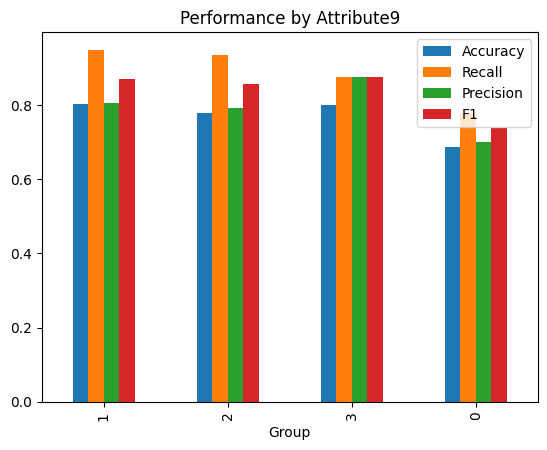


Demographic Parity → AgeGroup
Group 0: Positive Rate = 0.725
Group 1: Positive Rate = 0.863

Equal Opportunity → AgeGroup
Group 0: Recall = 0.860
Group 1: Recall = 0.956
   Group  Accuracy    Recall  Precision        F1
0      0  0.797101  0.860000   0.860000  0.860000
1      1  0.770992  0.956044   0.769912  0.852941


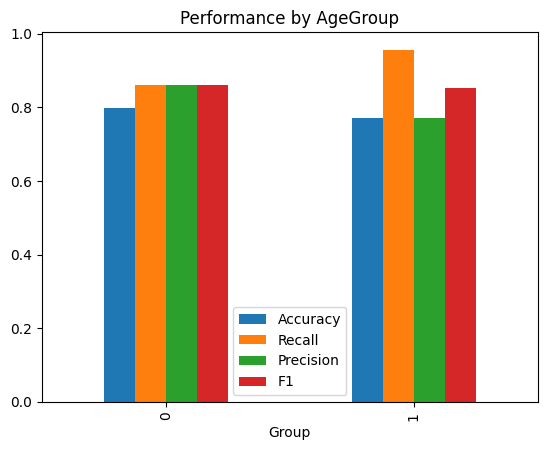

In [38]:
demographic_parity("Attribute9")
equal_opportunity("Attribute9")
plot_feature("Attribute9")

demographic_parity("AgeGroup")
equal_opportunity("AgeGroup")
plot_feature("AgeGroup")

Proxy Features

   Group  Accuracy    Recall  Precision        F1
0      0  0.791444  0.925373   0.810458  0.864111
1      1  0.428571  1.000000   0.200000  0.333333
2      2  0.833333  0.833333   1.000000  0.909091


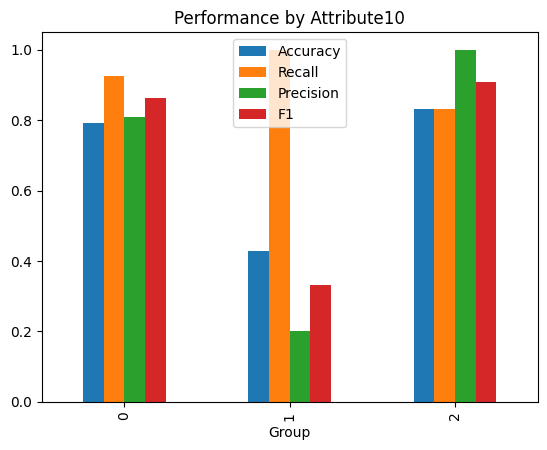

   Group  Accuracy    Recall  Precision        F1
0      0  0.774194  0.956522   0.785714  0.862745
1      2  0.793651  0.893617   0.840000  0.865979
2      3  0.806452  0.888889   0.800000  0.842105
3      1  0.750000  0.933333   0.756757  0.835821


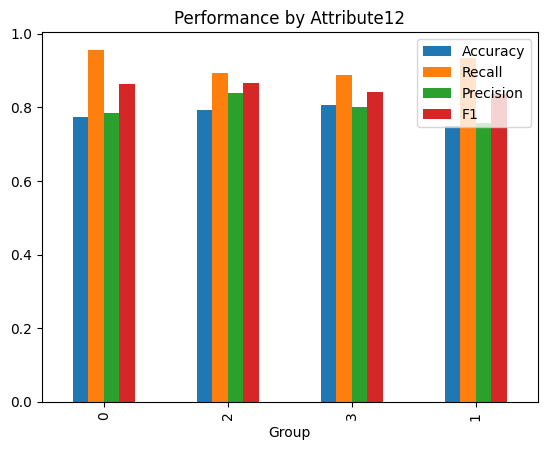

   Group  Accuracy    Recall  Precision        F1
0      2  0.810127  0.948276   0.820896  0.880000
1      0  0.733333  0.842105   0.761905  0.800000
2      1  0.500000  0.666667   0.500000  0.571429


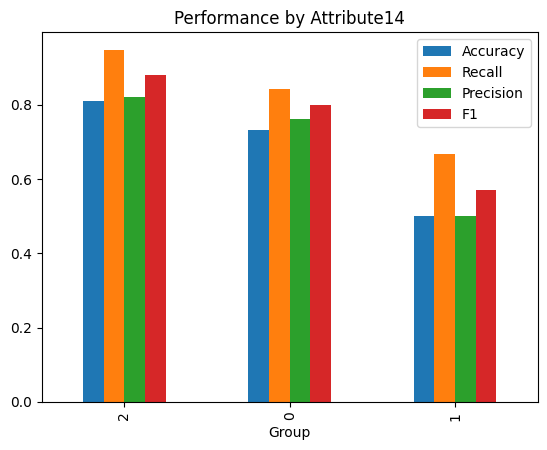

In [39]:
plot_feature("Attribute10")
plot_feature("Attribute12")
plot_feature("Attribute14")

Analysis
1. Does model performance differ across groups for each feature?

Yes, the model performance differs across groups for several features.

From the analysis, it can be observed that metrics such as accuracy, recall, precision, and F1-score vary between groups. For example, in the AgeGroup feature, one group shows slightly higher recall than the other. Similarly, in proxy features such as Attribute9 and Attribute10, different groups exhibit variations in prediction performance.

Although the differences are not extremely large, they indicate that the model does not perform equally across all groups, which suggests the presence of fairness issues.



 2. Which groups consistently receive worse predictions?

Certain groups receive comparatively worse predictions.

From the results:

Younger individuals (AgeGroup = 0) tend to have lower recall compared to older individuals
In proxy features such as Attribute9, some groups (e.g., Group 3) show lower recall and F1-score

Lower recall indicates that more actual positive cases (good credit customers) are misclassified. This means that these groups are more likely to be unfairly rejected.


 3. Do proxy features reveal additional bias compared to Sex/Age?

Yes, proxy features reveal additional bias that is not clearly visible when analyzing only explicit sensitive features such as Sex and Age.

Features like Attribute9, Attribute10, and Attribute12 show more noticeable variation in both positive prediction rates and recall values across groups. These features are likely to represent socio-economic factors indirectly.

This demonstrates that even when explicit sensitive attributes appear relatively fair, hidden bias can still exist through proxy variables.


 4. Why might these differences occur?

These differences may occur due to several reasons:

The dataset reflects historical patterns and socio-economic inequalities
Certain features are strongly correlated with financial status
Imbalance in group representation within the dataset
The model learns and replicates patterns present in the training data

As a result, the model may unintentionally favor certain groups over others, leading to biased outcomes.


 5. Why is this critical in real-world systems like credit scoring?

This is critical because machine learning models directly influence real-world decisions such as loan approval.

If the model is biased:

Deserving applicants may be wrongly rejected
Certain groups may face systematic disadvantages
It can lead to financial exclusion and inequality
It may raise ethical and regulatory concerns

Therefore, fairness analysis is essential to ensure that machine learning systems are reliable, ethical, and do not discriminate against any group.






Even small differences in model performance across groups can scale into significant real-world impact when applied to large populations, making fairness evaluation a crucial component of production machine learning systems.